# Clinical Readmission Analytics

## Exploratory Data Analysis (EDA)

This notebook explores patient demographics, healthcare utilization patterns, medication usage, and clinical characteristics associated with hospital readmissions.

### Objectives

- Understand readmission outcomes
- Explore demographic patterns
- Investigate healthcare utilization
- Examine medication-related factors
- Identify potential clinical insights

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

sns.set_theme(style="whitegrid")


In [33]:
df = pd.read_csv(
    "../data/cleaned_diabetes_readmission.csv"
)

df.shape

(101766, 45)

In [34]:
# quick dataset check

df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,Unknown,Pediatrics-Endocrinology,41,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,Unknown,Unknown,59,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,Unknown,11,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,Unknown,Unknown,44,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,Unknown,Unknown,51,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   admission_type_id         101766 non-null  int64 
 4   discharge_disposition_id  101766 non-null  int64 
 5   admission_source_id       101766 non-null  int64 
 6   time_in_hospital          101766 non-null  int64 
 7   payer_code                101766 non-null  object
 8   medical_specialty         101766 non-null  object
 9   num_lab_procedures        101766 non-null  int64 
 10  num_procedures            101766 non-null  int64 
 11  num_medications           101766 non-null  int64 
 12  number_outpatient         101766 non-null  int64 
 13  number_emergency          101766 non-null  int64 
 14  numb

### Understanding the Target Variable

##  Readmission Outcome Distribution

In [36]:
df["readmitted"].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [37]:
# percentage table

(
    df["readmitted"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

readmitted
NO     53.91
>30    34.93
<30    11.16
Name: proportion, dtype: float64

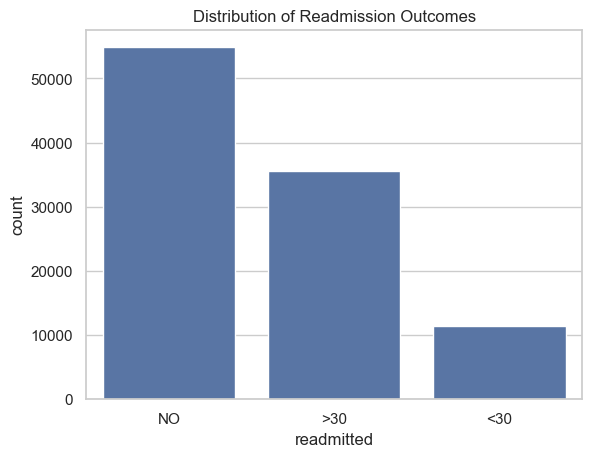

In [38]:
# Visualization

sns.countplot(
    data=df,
    x="readmitted"
)

plt.title("Distribution of Readmission Outcomes")
plt.show()

### Initial Observation

Most encounters resulted in no readmission.

A substantial proportion of patients experienced readmission after discharge, suggesting opportunities to investigate associated risk factors.

### Demographic Analysis

In [39]:
# Graphical Distribution
df["gender"].value_counts()

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

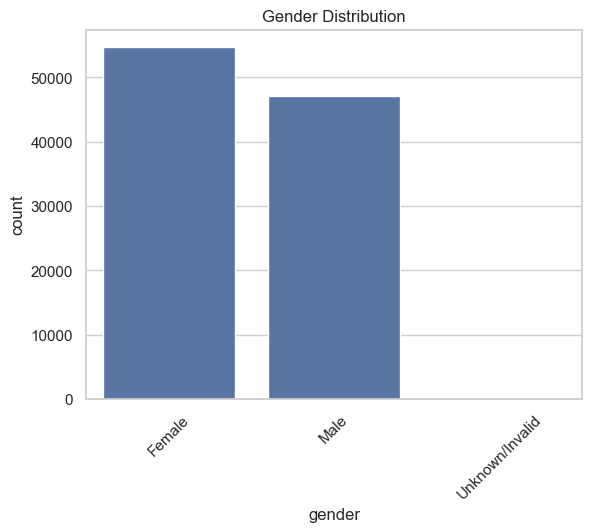

In [40]:
sns.countplot(
    data=df,
    x="gender"
)

plt.title("Gender Distribution")
plt.xticks(rotation=45)
plt.show()

In [41]:
# Age distribution

df["age"].value_counts()

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

In [42]:
# plotly version

fig = px.histogram(
    df,
    x="age",
    title="Age Group Distribution"
)

fig.show()

Do older age groups experience higher readmission rates?

In [43]:
# Age vs Readmission

age_readmission = pd.crosstab(
    df["age"],
    df["readmitted"],
    normalize="index"
).round(3)

age_readmission

readmitted,<30,>30,NO
age,,,
[0-10),0.019,0.161,0.820
[10-20),0.058,0.324,0.618
[20-30),0.142,0.308,0.550
[30-40),0.112,0.314,0.573
[40-50),0.106,0.338,0.555
[50-60),0.097,0.343,0.560
[60-70),0.111,0.351,0.537
[70-80),0.118,0.363,0.519
[80-90),0.121,0.362,0.517


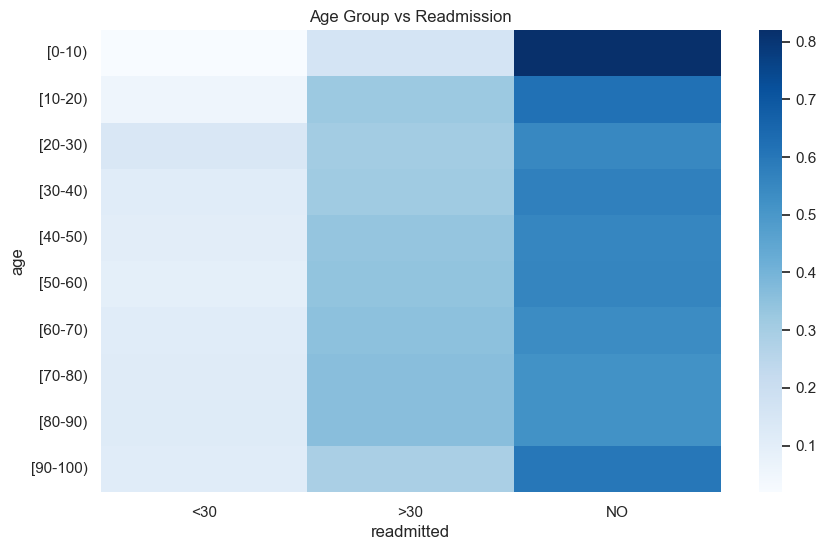

In [44]:
# Heatmap

plt.figure(figsize=(10,6))

sns.heatmap(
    age_readmission,
    cmap="Blues"
)

plt.title("Age Group vs Readmission")
plt.show()

## Healthcare Utilization

In [45]:
# Time in Hospital

df["time_in_hospital"].describe()

count    101766.000000
mean          4.395987
std           2.985108
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64

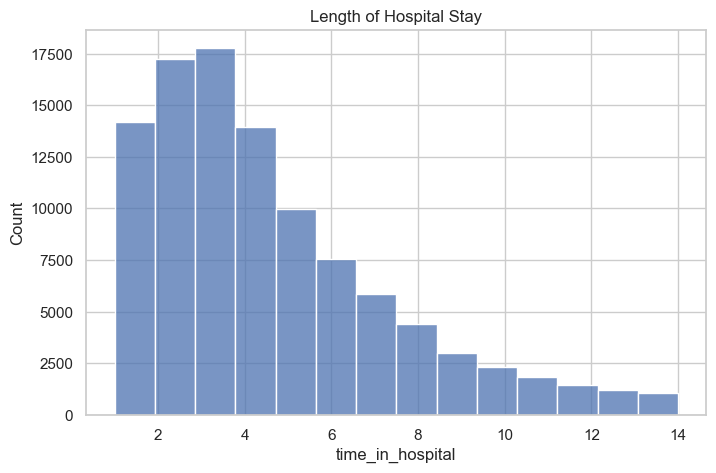

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["time_in_hospital"],
    bins=14
)

plt.title("Length of Hospital Stay")
plt.show()

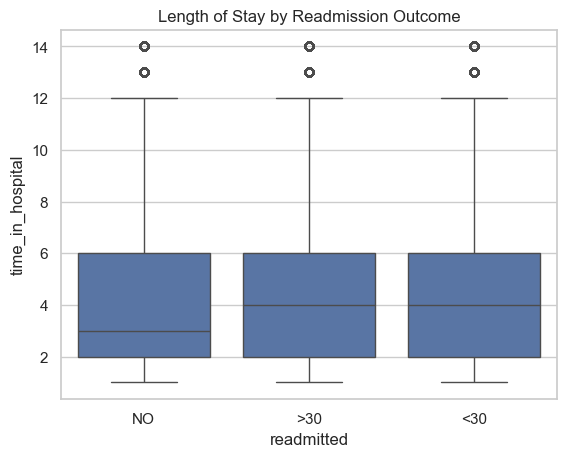

In [47]:
# Time in Hospital vs Readmission

sns.boxplot(
    data=df,
    x="readmitted",
    y="time_in_hospital"
)

plt.title(
    "Length of Stay by Readmission Outcome"
)

plt.show()

Do patients with longer hospital stays exhibit higher readmission rates?

### Medication Analysis

In [48]:
# Number of Medications

df["num_medications"].describe()

count    101766.000000
mean         16.021844
std           8.127566
min           1.000000
25%          10.000000
50%          15.000000
75%          20.000000
max          81.000000
Name: num_medications, dtype: float64

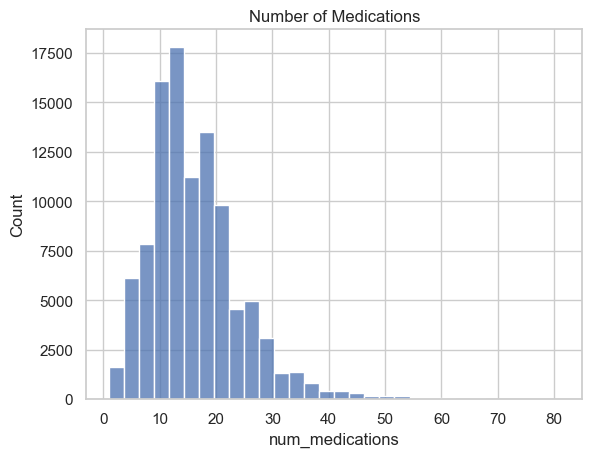

In [49]:
# Distribution

sns.histplot(
    df["num_medications"],
    bins=30
)

plt.title("Number of Medications")
plt.show()

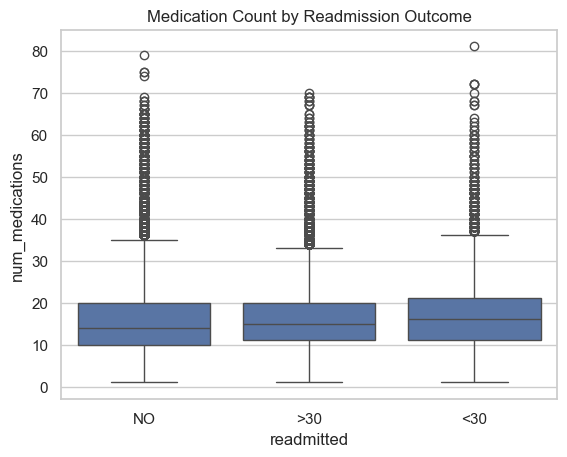

In [50]:
# Medications vs Readmission

sns.boxplot(
    data=df,
    x="readmitted",
    y="num_medications"
)

plt.title(
    "Medication Count by Readmission Outcome"
)

plt.show()

Patients receiving larger numbers of medications may represent more clinically complex cases.

### Prior Healthcare Utilization

In [51]:
df["number_outpatient"].describe()

count    101766.000000
mean          0.369357
std           1.267265
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          42.000000
Name: number_outpatient, dtype: float64

In [52]:
# Emergency visits

df["number_emergency"].describe()

count    101766.000000
mean          0.197836
std           0.930472
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          76.000000
Name: number_emergency, dtype: float64

In [53]:
# Inpatient Visits

df["number_inpatient"].describe()

count    101766.000000
mean          0.635566
std           1.262863
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64

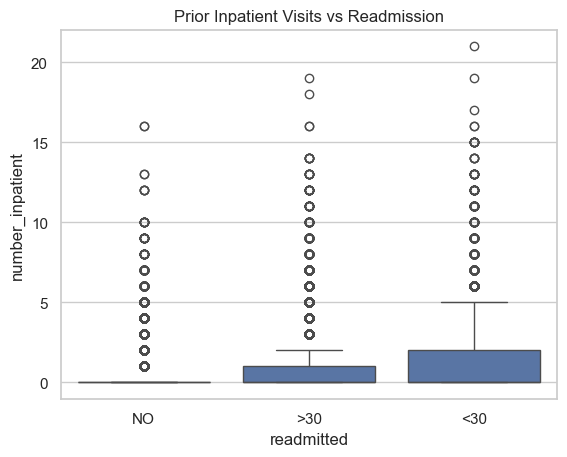

In [54]:
# Compare Against Readmission

sns.boxplot(
    data=df,
    x="readmitted",
    y="number_inpatient"
)

plt.title(
    "Prior Inpatient Visits vs Readmission"
)

plt.show()

### Clinical Variables

In [55]:
# Diabetes Medication Status

df["diabetesMed"].value_counts()

diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64

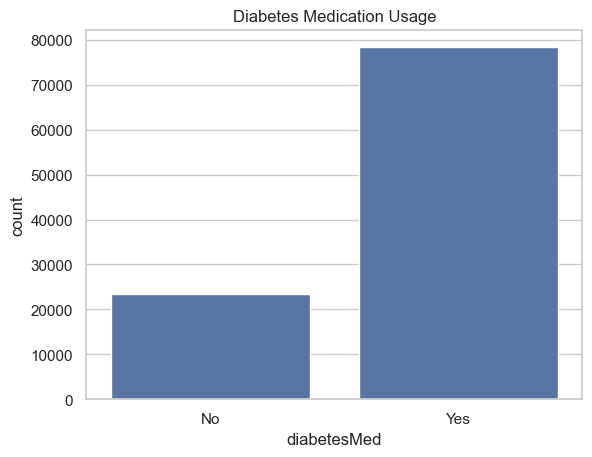

In [56]:
#plot

sns.countplot(
    data=df,
    x="diabetesMed"
)

plt.title(
    "Diabetes Medication Usage"
)

plt.show()

In [57]:
# A1C result

df["A1Cresult"].value_counts()

A1Cresult
Not Measured    84748
>8               8216
Norm             4990
>7               3812
Name: count, dtype: int64

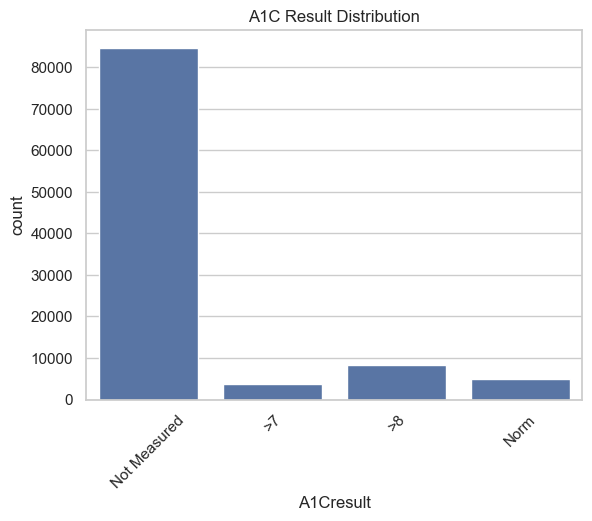

In [58]:
# plot

sns.countplot(
    data=df,
    x="A1Cresult"
)

plt.title(
    "A1C Result Distribution"
)

plt.xticks(rotation=45)
plt.show()

### Correlation Analysis

In [59]:
# Numeric Variables

numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

In [60]:
# Correlation Matrix

corr = numeric_df.corr()

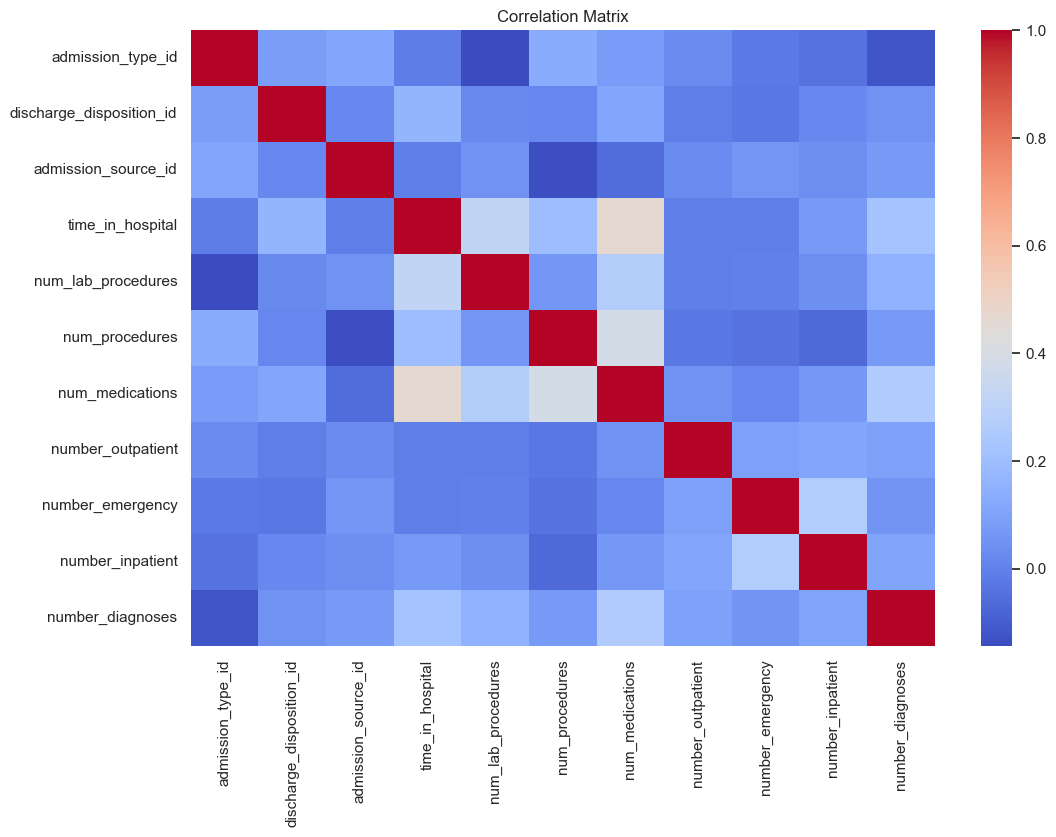

In [61]:
# Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## Key Findings

### Demographics

- Age distribution is concentrated among older adults.
- Readmission patterns vary across age groups.

### Healthcare Utilization

- Patients with longer hospital stays may exhibit different readmission outcomes.
- Prior inpatient utilization appears associated with readmission.

### Medications

- Medication burden varies substantially across patients.
- Diabetes medication usage is highly prevalent.

### Clinical Variables

- A1C testing was not performed for many encounters.
- Several variables demonstrate potential clinical relevance for future analysis.